# Financial Fraud Detection Analysis – Data Cleaning, Wrangling & Preprocessing

Author: Nick Peril  
Project: TKH Phase II Portfolio

### Objective
To clean and pre-process the dataset in preparation for modeling.

### Importing necessary packages:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading my dataset:

In [2]:
df = pd.read_csv('/Users/saadult/financial_fraud/data/caishen_bank_transactions.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Checking for missing values:

In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

*No missing values in all columns, dataset is complete.* 

### Checking for duplicate values:

In [5]:
df.duplicated().sum()

np.int64(0)

*There are no exact duplicate rows which means each transaction is unique.*

### Dropping irrelevant columns:

In [6]:
df = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

In [7]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

*I dropped `nameOrig` and `nameDest` columns since they are just account IDs, not really useful for predicting fraud. I also dropped `isFlaggedFraud` to avoid data leakage, as it is a rule-based flag derived from transaction amount and could bias the model*

### Checking data types:
Just making sure that each columns is in the right format. Correct data types ensure that transformation (like scaling, encoding, log transforms) work properly and prevent errors during modeling.

In [8]:
df.dtypes

step                int64
type               object
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

### Encoding categorical variables:
I will one-hot encode the `type` column so the model can understand transaction categories as numerical features without assuming any order between them.

In [9]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)      # setting drop_first to 'True' to avoid redundancy since having all dummy columns would give duplicate information

In [10]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

*The `type` column was successfully converted into numerical dummy variables, allowing the model to interpret transaction categories while avoiding redundancy by dropping one base category.*

### Handling outliers/highly skewed features:

In [11]:
df.skew(numeric_only=True)

step               0.375177
amount            30.993949
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
oldbalanceDest    19.921758
newbalanceDest    19.352302
isFraud           27.779538
type_CASH_OUT      0.621319
type_DEBIT        12.270876
type_PAYMENT       0.684258
type_TRANSFER      3.005134
dtype: float64

**Although several numerical features (such as amount, oldbalanceOrg, and oldbalanceDest) exhibit high positive skewness, <u>log transformation was not applied in this case</u>. <u>Since I’m using tree-based models (Random Forest and Gradient Boosting), they don’t really care about skewed data because they split values based on rules, not distances</u>. Log transform is still useful for cleaner visuals during EDA, but for this model, it’s not necessary. So I kept the original values to keep things simple.**

### Feature Engineering:
In this step, I will create new features that can help the model better detect fraud. Instead of just relying on the original columns, I’m adding features (like balance differences) that highlight unusual patterns in transactions.

Fraud often leaves behind small inconsistencies—like balances not adding up correctly—so these engineered features make it easier for the model to spot suspicious behavior.

#### <u>Balance Error Feature</u>
These features check if the money movement makes sense. Normally, the old balance minus the new balance should match the transaction amount. If it doesn’t, that’s a red flag. Fraud transactions often leave these kinds of inconsistencies.

In [12]:
df["orig_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [13]:
df[[
    "oldbalanceOrg", "newbalanceOrig", "orig_balance_diff",
    "oldbalanceDest", "newbalanceDest", "dest_balance_diff"
]].head()

,oldbalanceOrg,newbalanceOrig,orig_balance_diff,oldbalanceDest,newbalanceDest,dest_balance_diff
0,170136.0,160296.36,9839.64,0.0,0.0,0.0
1,21249.0,19384.72,1864.28,0.0,0.0,0.0
2,181.0,0.00,181.00,0.0,0.0,0.0
3,181.0,0.00,181.00,21182.0,0.0,-21182.0
4,41554.0,29885.86,11668.14,0.0,0.0,0.0


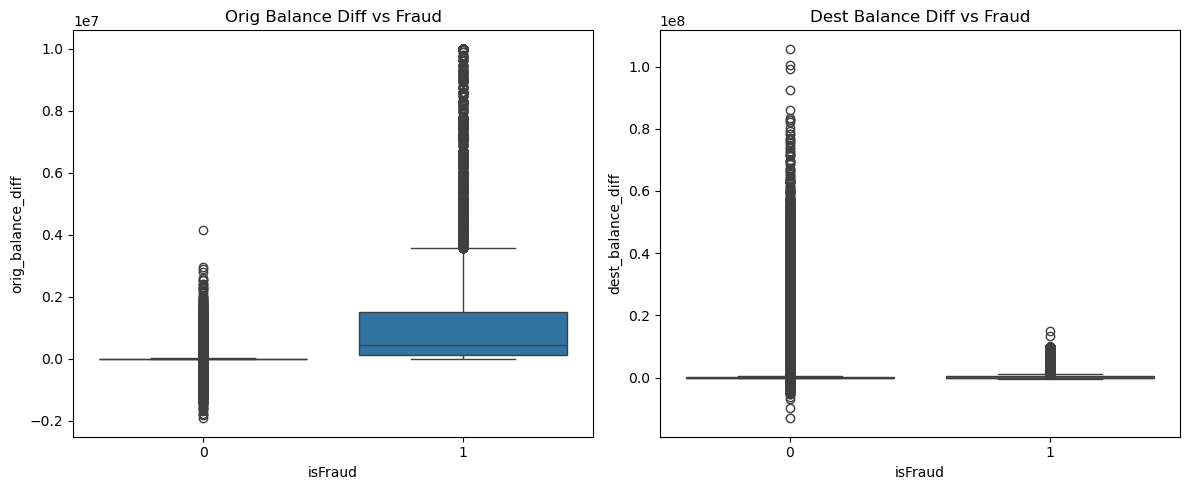

In [23]:
# Creating a figure with 1 row and 2 columns of subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting boxplot for origin balance difference vs fraud status
# This helps visualize how money leaving the sender differs between fraud and non-fraud cases
sns.boxplot(x="isFraud", y="orig_balance_diff", data=df, ax=axes[0])

# Setting title for the first subplot for clarity
axes[0].set_title("Orig Balance Diff vs Fraud")

# Plotting boxplot for destination balance difference vs fraud status
# This shows how money received behaves across fraud vs non-fraud transactions
sns.boxplot(x="isFraud", y="dest_balance_diff", data=df, ax=axes[1])

# Setting title for the second subplot
axes[1].set_title("Dest Balance Diff vs Fraud")

# Adjusting layout to prevent overlapping elements and improve readability
plt.tight_layout()

# Saving chart image to docs folder
plt.savefig("../docs/boxplot_bal_diff_fraud.png", bbox_inches='tight')

# Displaying the plots
plt.show()

* Fraud transactions show a much bigger change in the origin balance, meaning money is usually being pulled out quickly
* Non-fraud transactions mostly stay closer to zero, while fraud ones have larger and more spread-out values
* For destination balance, fraud cases tend to have smaller and tighter changes, suggesting money is being transferred but not sitting long in the destination account
* Overall, unusual balance changes, especially from the sender, seem to be a strong signal of fraud 

#### <u>Zero Balance Flag</u>
These features mark accounts that start with zero balance. Fraud accounts are often empty or newly created, and they tend to behave differently. Flagging them helps the model spot suspicious patterns faster.

In [15]:
df["is_orig_empty"] = (df["oldbalanceOrg"] == 0).astype(int)
df["is_dest_empty"] = (df["oldbalanceDest"] == 0).astype(int)

In [16]:
df[["oldbalanceOrg", "is_orig_empty", "oldbalanceDest", "is_dest_empty"]].head()

,oldbalanceOrg,is_orig_empty,oldbalanceDest,is_dest_empty
0,170136.0,0,0.0,1
1,21249.0,0,0.0,1
2,181.0,0,0.0,1
3,181.0,0,21182.0,0
4,41554.0,0,0.0,1


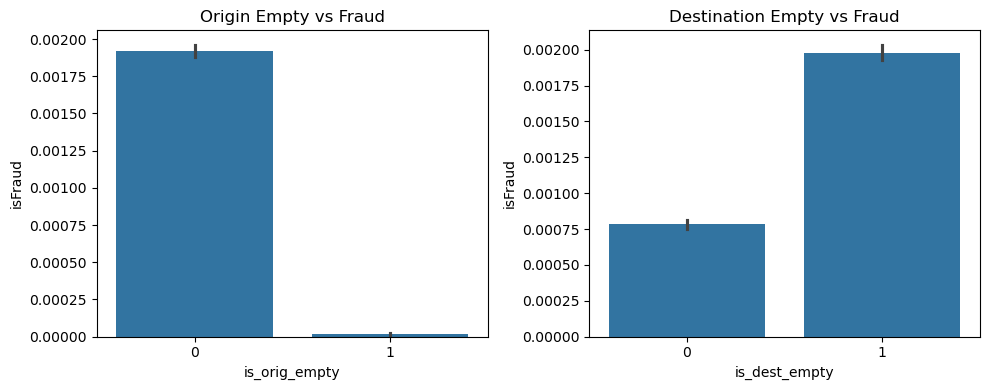

In [24]:
# Creating a figure with 2 subplots side-by-side to compare origin and destination behavior
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plotting bar chart showing average fraud rate based on whether the origin account is empty or not
# This helps identify if fraud is more likely from accounts with or without initial balance
sns.barplot(x="is_orig_empty", y="isFraud", data=df, ax=axes[0])

# Setting title for the first subplot for clarity
axes[0].set_title("Origin Empty vs Fraud")

# Plotting bar chart showing average fraud rate based on whether the destination account is empty
# This helps reveal if fraud tends to send money into empty or inactive accounts
sns.barplot(x="is_dest_empty", y="isFraud", data=df, ax=axes[1])

# Setting title for the second subplot
axes[1].set_title("Destination Empty vs Fraud")

# Adjusting spacing to prevent overlap and improve readability
plt.tight_layout()

# Saving chart image to docs folder
plt.savefig("../docs/barplot_empty_fraud.png", bbox_inches='tight')

# Displaying the plots
plt.show()


* Accounts with zero initial balance show lower fraud rates, suggesting fraud tends to occur in accounts with existing funds
* When the destination account is empty, fraud cases are actually slightly higher, suggesting fraudsters may be moving money into newly created or inactive accounts
* This pattern shows fraud is more about draining funded accounts and transferring to fresh ones
* Both features (is_orig_empty and is_dest_empty) look useful since they capture real behavioral patterns in fraud activity 

### Final check:

In [18]:
print(df.info())
print(df.head(10))
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 15 columns):
 #   Column             Dtype  
---  ------             -----  
 0   step               int64  
 1   amount             float64
 2   oldbalanceOrg      float64
 3   newbalanceOrig     float64
 4   oldbalanceDest     float64
 5   newbalanceDest     float64
 6   isFraud            int64  
 7   type_CASH_OUT      bool   
 8   type_DEBIT         bool   
 9   type_PAYMENT       bool   
 10  type_TRANSFER      bool   
 11  orig_balance_diff  float64
 12  dest_balance_diff  float64
 13  is_orig_empty      int64  
 14  is_dest_empty      int64  
dtypes: bool(4), float64(7), int64(4)
memory usage: 558.2 MB
None
   step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1   9839.64      170136.00       160296.36             0.0   
1     1   1864.28       21249.00        19384.72             0.0   
2     1    181.00         181.00            0.00             0.0   
3    

In [19]:
print("Final shape:", df.shape)

Final shape: (6362620, 15)


### Download Cleaned Dataset:

In [22]:
# Save cleaned dataset to CSV
df.to_csv("/Users/saadult/financial_fraud/data/cleaned_fraud_data.csv", index=False)

### Summary:
* Checked for missing values and duplicate rows and found no missing values and exact duplicates, ensuring data is complete and each transaction is unique
* Removed irrelevant columns (nameOrig, nameDest, isFlaggedFraud) as they do not contribute meaningful predictive value or could lead to data leakage.
* Verified data types to ensure compatibility with modeling techniques
* Applied one-hot encoding to the `type` column to convert categorical data into numerical features while avoiding multicollinearity using drop_first=True
* Analyzed skewness of numerical features but *did not apply log transformation*, **as tree-based models (Random Forest and Gradient Boosting) are robust to skewed data and do not require feature scaling**
* Engineered new features such as balance differences and account status indicators (is_orig_empty, is_dest_empty) to capture transaction behavior patterns
* Explored relationships between engineered features and fraud to validate their usefulness